In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# 1. Load dữ liệu
# Lưu ý: Cần chắc chắn file csv nằm đúng đường dẫn 'data/' hoặc cùng thư mục
df = pd.read_csv(r'C:\Users\Hi\Desktop\RetentIO_Project\data\bank_churn_dataset_80k.csv')

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (80000, 26)


,id,full_name,credit_sco,gender,age,occupation,balance,monthly_ir,address,origin_province,tenure_ye,married,nums_card,nums_service,active_member,last_active_date,last_transaction_month,created_date,exit,customer_segment,engagement_score,loyalty_level,digital_behavior,risk_score,risk_segment,cluster_group
0,1,Đặng Văn Vũ,725,male,55,Chủ Doanh nghiệp nhỏ,177306004,121000000,Phường An Hội (BT),TP. Hồ Chí Minh,0,2,4,8,True,03/04/2025,91038993,27/02/2025,False,Priority,90,Bronze,mobile,0.0359,Low,4
1,2,Bùi Hữu Phúc,689,male,45,Nội trợ/Sinh viên,1927416,5000000,Phường Bến Thành (Q1),Đồng Nai,3,1,3,2,True,14/05/2025,3255569,29/07/2021,False,Mass,63,Gold,mobile,0.2664,Low,2
2,3,Lê Văn Mai,702,female,44,Chủ Doanh nghiệp nhỏ,304931745,109000000,Phường Hòa Bình (Q11),TP. Hồ Chí Minh,4,0,2,8,False,10/09/2021,0,03/03/2021,False,Priority,36,Silver,offline,0.1343,Low,4
3,4,Dương Trần Nhiên,766,male,44,Chủ Doanh nghiệp nhỏ,50615501,79000000,Phường 7 (Q7),TP. Hồ Chí Minh,3,0,4,3,False,04/03/2025,0,12/02/2022,False,Priority,23,Bronze,offline,0.2185,Low,4
4,5,Dương Thu Linh,677,female,77,Giáo viên/Giảng viên,40532432,25000000,Phường Thắng Lợi (Q10),TP. Hồ Chí Minh,2,1,4,3,False,06/08/2022,0,24/07/2022,False,Emerging,23,Bronze,offline,0.2942,Low,2


In [9]:
# 2. Xử lý dữ liệu ngày tháng
# Dữ liệu của bạn có format dd/mm/yyyy
date_cols = ['created_date', 'last_active_date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')

# Kiểm tra xem có dòng nào bị lỗi ngày tháng (NaT) không
print("Số lượng giá trị lỗi ngày tháng:")
print(df[date_cols].isna().sum())

# Loại bỏ dòng lỗi (nếu ít) để tránh lỗi tính toán sau này
df.dropna(subset=date_cols, inplace=True)

Số lượng giá trị lỗi ngày tháng:
created_date        0
last_active_date    0
dtype: int64


Ngày chốt dữ liệu (Snapshot Date): 2025-07-02 00:00:00


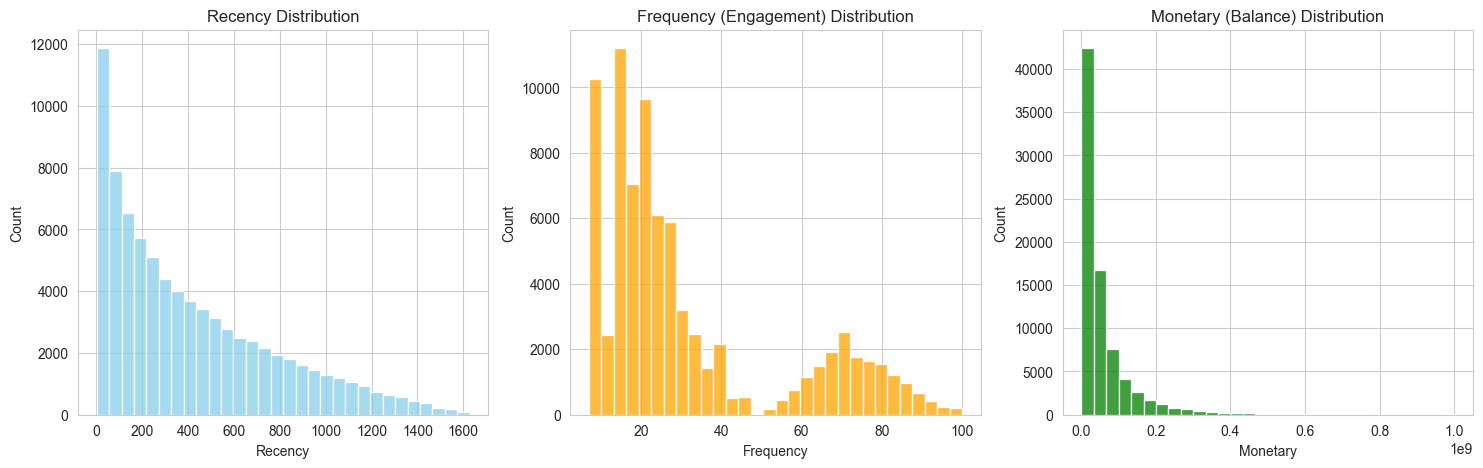

In [10]:
# 3. Tính toán R - F - M Features

# Giả định ngày phân tích là ngày active cuối cùng trong data + 1 ngày
snapshot_date = df['last_active_date'].max() + pd.Timedelta(days=1)
print(f"Ngày chốt dữ liệu (Snapshot Date): {snapshot_date}")

# --- RECENCY ---
# Số ngày kể từ lần cuối tương tác
df['Recency'] = (snapshot_date - df['last_active_date']).dt.days

# --- FREQUENCY ---
# Dùng Engagement Score làm proxy cho tần suất tương tác
# (Khách tương tác nhiều -> điểm engagement cao)
df['Frequency'] = df['engagement_score']

# --- MONETARY ---
# Dùng Balance làm proxy cho giá trị
df['Monetary'] = df['balance']

# Xem phân phối của RFM
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Recency'], bins=30, ax=ax[0], color='skyblue').set_title('Recency Distribution')
sns.histplot(df['Frequency'], bins=30, ax=ax[1], color='orange').set_title('Frequency (Engagement) Distribution')
sns.histplot(df['Monetary'], bins=30, ax=ax[2], color='green').set_title('Monetary (Balance) Distribution')
plt.show()

In [11]:
# 4. Chuẩn hóa dữ liệu

# Kiểm tra độ lệch (Skewness)
print(f"Monetary Skewness: {df['Monetary'].skew()}")

# Apply Log Transformation cho Monetary để giảm độ lệch (tránh số âm bằng cách cộng 1)
df['Monetary_Log'] = np.log1p(df['Monetary'])

# Chọn features để đưa vào mô hình
rfm_features = df[['Recency', 'Frequency', 'Monetary_Log']]

# Scaling (StandardScaler: Mean=0, Std=1)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled = pd.DataFrame(rfm_scaled, columns=rfm_features.columns)
print("Dữ liệu sau khi chuẩn hóa:")
print(rfm_scaled.head())

Monetary Skewness: 4.119595153546241
Dữ liệu sau khi chuẩn hóa:
    Recency  Frequency  Monetary_Log
0 -0.886495   2.482441      1.503792
1 -0.999634   1.332267     -2.470709
2  2.703573   0.182094      1.980387
3 -0.803711  -0.371694      0.401880
4  1.792949  -0.371694      0.206609


In [12]:
# 5. K-Means Clustering
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['Cluster_Id'] = kmeans.fit_predict(rfm_scaled)

# Tính giá trị trung bình của từng cụm (để hiểu ý nghĩa cụm)
# Ta tính trên giá trị gốc (chưa log/scale) để dễ đọc
cluster_summary = df.groupby('Cluster_Id')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()
cluster_summary['Count'] = df.groupby('Cluster_Id')['id'].count().values

print("--- Trung bình các chỉ số theo từng cụm ---")
print(cluster_summary)

--- Trung bình các chỉ số theo từng cụm ---
   Cluster_Id      Recency  Frequency      Monetary  Count
0           0   340.450567  17.279511  1.658137e+07  26278
1           1  1006.293036  20.026593  6.732442e+07  15493
2           2   364.129017  24.578680  1.242501e+08  21098
3           3    39.764871  73.266476  4.637464e+07  17131


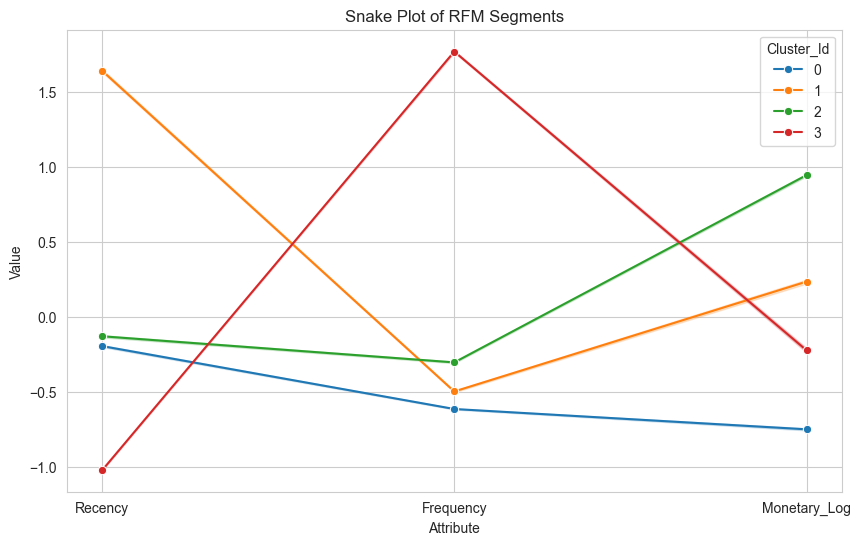

--- Kết quả phân nhóm khách hàng ---
Customer_Segment_RFM
Hibernating (Low Value)    26278
VIP At Risk                21098
Loyal/Active Users         17131
Churned (Inactive)         15493
Name: count, dtype: int64


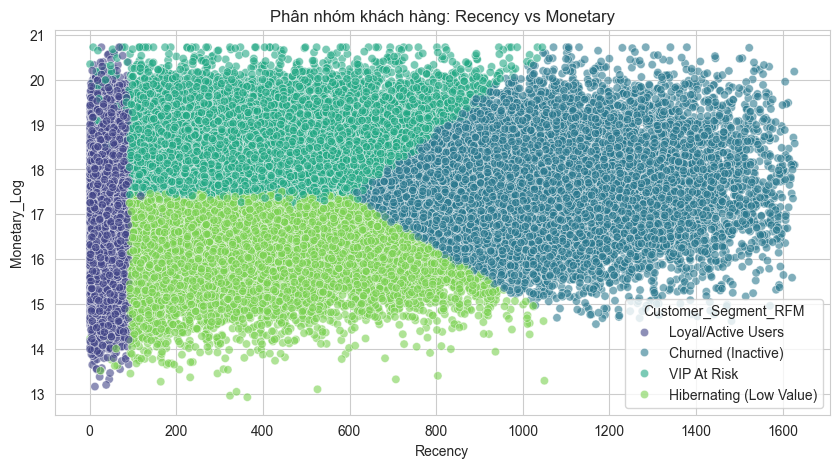

In [ ]:
# 6. Trực quan hóa và đặt tên (Mapping)

# Melt dữ liệu để vẽ Snake Plot (Biểu đồ đường zic-zac so sánh các cụm)
df_normalized = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary_Log'])
df_normalized['Cluster_Id'] = df['Cluster_Id']
df_melt = pd.melt(df_normalized.reset_index(),
                  id_vars=['Cluster_Id'],
                  value_vars=['Recency', 'Frequency', 'Monetary_Log'],
                  var_name='Attribute',
                  value_name='Value')

plt.figure(figsize=(10, 6))
sns.lineplot(x='Attribute', y='Value', hue='Cluster_Id', data=df_melt, palette='tab10', marker="o")
plt.title('Snake Plot of RFM Segments')
plt.show()

# --- GÁN NHÃN (LOGIC MẪU - Cần check lại với output thực tế của bạn) ---
# Quy tắc suy luận từ biểu đồ:
# - Cụm nào Recency THẤP, Frequency CAO, Monetary CAO -> VIP (Champions)
# - Cụm nào Recency THẤP, Frequency THẤP, Monetary THẤP -> Mới/Vãng lai (Low Value)
# - Cụm nào Recency CAO (lâu không quay lại) -> Nguy cơ rời bỏ (At Risk/Churned)

# Logic mapping dựa trên phân tích Cluster Summary (Đáp án: Đặc điểm nhận dạng -> Nhãn đề xuất -> Ý nghĩa Business tiếp theo cho dự án)
# - Cụm 0: Recency TB, Tiền ít, Engagement thấp -> Hibernating (Ngủ đông/Vãng lai) -> Có thể bỏ qua hoặc ưu tiên thấp vì giá trị khai thác không cao hoặc đã bỏ đi quá lâu.
# - Cụm 1: Recency RẤT CAO (>1000 ngày) -> Churned (Đã rời bỏ lâu) -> Có thể bỏ qua hoặc ưu tiên thấp vì giá trị khai thác không cao hoặc đã bỏ đi quá lâu.
# - Cụm 2: Tiền nhiều (VIP) nhưng Engagement thấp & Recency cao -> At Risk (Cần cứu VIP này) -> (Nhóm quan trọng nhất) Có tiền (Monetary cao nhất) nhưng Recency xấu (~1 năm k quay lại)
# - Cụm 3: Recency rất thấp (mới dùng), Engagement cao nhất -> Loyal/Active (Khách hàng tốt) -> Đang ổn, chỉ cần duy trì (Cross-sell nhẹ)

segment_map = {
    0: 'Hibernating (Low Value)',  # Nhóm vãng lai/ngủ đông, tiền ít
    1: 'Churned (Inactive)',       # Đã bỏ đi rất lâu
    2: 'VIP At Risk',              # Khách giàu nhưng đang chán (nguy hiểm!)
    3: 'Loyal/Active Users'        # Khách hàng đang hoạt động tốt
}

df['Customer_Segment_RFM'] = df['Cluster_Id'].map(segment_map)

# Kiểm tra lại kết quả sau khi gán nhãn
print("--- Kết quả phân nhóm khách hàng ---")
print(df['Customer_Segment_RFM'].value_counts())

# Vẽ biểu đồ
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Recency', y='Monetary_Log', hue='Customer_Segment_RFM', palette='viridis', alpha=0.6)
plt.title('Phân nhóm khách hàng: Recency vs Monetary')
plt.show()

In [15]:
# 7. Lưu file đã xử lý
# Ta lưu lại các cột cần thiết cho các model sau
cols_to_keep = [
    'id', 'full_name', 'created_date', 'last_active_date', # Định danh & Thời gian
    'Recency', 'Frequency', 'Monetary', 'Customer_Segment_RFM', # RFM Features
    'nums_service', 'balance', 'monthly_ir', 'age', 'credit_sco', 'occupation', # Features cho Churn/CLV
    'exit', 'risk_score' # Target labels
]

df[cols_to_keep].to_csv(r'C:\Users\Hi\Desktop\RetentIO_Project\data\processed_bank_data_rfm.csv', index=False)
print("Đã lưu file: processed_bank_data_rfm.csv")

Đã lưu file: processed_bank_data_rfm.csv
